# HumanLens AI — Multimodal Fusion Engine

**Member 3 — Research / ML Lead**

This notebook develops the first research baseline for combining
text, voice, and facial-expression signals into an interpretable
multimodal emotional/escalation state.

### Research Principle

HumanLens AI uses a simple and explainable weighted fusion strategy
for the initial research version rather than an opaque end-to-end
multimodal model.

### Modalities

- Text: toxicity / aggression / emotional intensity
- Voice: vocal activation / intensity / speech-related features
- Face: expression-related activation
- Optional behavioral context: longitudinal stress / sleep / pressure

### Important Safety Boundary

The fused score represents an estimated escalation state.
It does NOT represent a diagnosis, personality judgment, or the
person's true internal emotional state.

The system should support reflection and de-escalation rather than
punish disagreement or ordinary communication.

## Research Questions

### Primary Research Question

Does the HumanLens AI **"Before You Speak"** intervention reduce the
toxicity or escalation level of potentially harmful communication?

### Secondary Research Questions

1. How often does the intervention lead to a message being modified or
   rewritten?

2. Does an intervention reduce the measured toxicity score between the
   original and revised message?

3. Does the intervention reduce the overall escalation level?

4. What proportion of interventions are accepted, ignored, or rejected?

5. How often does the system intervene on content that is ultimately
   considered low-risk?

6. Does the intervention preserve user agency by allowing the user to
   continue without modification?

7. What is the computational latency introduced by the intervention?

### Evaluation Hypothesis

**H1:** Messages that undergo a "Before You Speak" intervention will,
on average, show a lower toxicity/escalation score after revision than
their original version.

**H0:** There will be no meaningful difference between the original and
post-intervention toxicity/escalation scores.

### Safety Evaluation Principle

Effectiveness alone is not sufficient.

The intervention should also minimize unnecessary interventions and
should not treat ordinary disagreement, criticism, or non-harmful
communication as harmful solely because of sentiment, profanity, or
controversial content.

## Intervention Evaluation Methodology

The intervention will be evaluated using a controlled pre-intervention
and post-intervention comparison.

### Evaluation Flow

Original Message
        ↓
HumanLens Risk / Escalation Analysis
        ↓
Intervention Trigger
        ↓
"Before You Speak"
        ↓
User Action
        ↓
Revised / Unchanged Message
        ↓
Post-Intervention Analysis
        ↓
Outcome Comparison

### Evaluation Variables

For each evaluated message, record:

- `original_text`
- `original_toxicity`
- `original_escalation_score`
- `intervention_triggered`
- `user_action`
- `revised_text`
- `revised_toxicity`
- `revised_escalation_score`
- `toxicity_change`
- `escalation_change`
- `intervention_latency_ms`

### User Actions

The intervention is modeled using three possible outcomes:

1. **Rewrite** — the user modifies the message.
2. **Proceed** — the user continues without changing the message.
3. **Dismiss** — the user explicitly dismisses the intervention.

### Effectiveness Measures

#### Toxicity Reduction

\[
\Delta Toxicity =
Toxicity_{original} - Toxicity_{revised}
\]

A positive value indicates a reduction in measured toxicity.

#### Escalation Reduction

\[
\Delta Escalation =
Escalation_{original} - Escalation_{revised}
\]

A positive value indicates a reduction in escalation level.

#### Rewrite Rate

\[
Rewrite\ Rate =
\frac{Number\ of\ rewritten\ messages}
{Number\ of\ triggered\ interventions}
\]

#### Intervention Acceptance Rate

\[
Acceptance\ Rate =
\frac{Number\ of\ messages\ modified}
{Number\ of\ triggered\ interventions}
\]

### Important Research Limitation

If real user interaction data are unavailable, this notebook will use
controlled demonstration/simulation data to validate the evaluation
pipeline.

Such results must NOT be presented as evidence that real users changed
their behavior.

The purpose of the simulation is to verify the measurement methodology
and reporting pipeline so that real user-study data can be evaluated later.

In [1]:
# ============================================================
# STEP 1 — Imports and Project Setup
# ============================================================

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Project root
# ------------------------------------------------------------

PROJECT_ROOT = Path(
    r"E:\VS CODE\Data_Science\HUMANLENS AI\research_ml"
)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Project root:", PROJECT_ROOT)
print("Project root exists:", PROJECT_ROOT.exists())
print("Results directory:", RESULTS_DIR)

Project root: E:\VS CODE\Data_Science\HUMANLENS AI\research_ml
Project root exists: True
Results directory: E:\VS CODE\Data_Science\HUMANLENS AI\research_ml\results


## 2. Multimodal Fusion Methodology

The first HumanLens AI fusion baseline uses a weighted average of
normalized modality scores.

For three available modalities:

    Fusion Score =
        w_text × Text Score
      + w_voice × Voice Score
      + w_face × Face Score

where:

    w_text + w_voice + w_face = 1

The initial weights are:

    Text  = 0.50
    Voice = 0.25
    Face  = 0.25

Text receives the highest initial weight because the current HumanLens
pipeline has the most directly measurable semantic evidence from
toxicity/aggression analysis.

These are research baseline weights, not clinically validated weights.
They must be evaluated and potentially recalibrated using validation data.

In [2]:
# ============================================================
# STEP 3 — Initial Fusion Weights
# ============================================================

FUSION_WEIGHTS = {
    "text": 0.50,
    "voice": 0.25,
    "face": 0.25
}

weight_sum = sum(FUSION_WEIGHTS.values())

print("Fusion weights:")
for modality, weight in FUSION_WEIGHTS.items():
    print(f"{modality.capitalize():<8}: {weight:.2f}")

print("\nWeight sum:", weight_sum)

assert np.isclose(weight_sum, 1.0)

print("✅ Weight validation passed.")

Fusion weights:
Text    : 0.50
Voice   : 0.25
Face    : 0.25

Weight sum: 1.0
✅ Weight validation passed.


In [3]:
# ============================================================
# STEP 4 — Controlled Multimodal Scenarios
# ============================================================

scenarios = [
    {
        "scenario": "Calm Interaction",
        "text_score": 0.15,
        "voice_score": 0.20,
        "face_score": 0.18
    },
    {
        "scenario": "Mild Frustration",
        "text_score": 0.45,
        "voice_score": 0.42,
        "face_score": 0.40
    },
    {
        "scenario": "Elevated Tension",
        "text_score": 0.72,
        "voice_score": 0.68,
        "face_score": 0.65
    },
    {
        "scenario": "High Escalation",
        "text_score": 0.95,
        "voice_score": 0.88,
        "face_score": 0.84
    }
]

scenario_df = pd.DataFrame(scenarios)

display(scenario_df)

,scenario,text_score,voice_score,face_score
0,Calm Interaction,0.15,0.20,0.18
1,Mild Frustration,0.45,0.42,0.40
2,Elevated Tension,0.72,0.68,0.65
3,High Escalation,0.95,0.88,0.84


In [4]:
# ============================================================
# STEP 5 — Explainable Weighted Fusion
# ============================================================

def calculate_fusion_score(
    text_score,
    voice_score,
    face_score,
    weights=FUSION_WEIGHTS
):
    """
    Calculate an interpretable weighted multimodal score.

    All modality scores must be normalized to [0, 1].
    """

    scores = {
        "text": float(text_score),
        "voice": float(voice_score),
        "face": float(face_score)
    }

    # Validate score range
    for modality, score in scores.items():
        if not 0.0 <= score <= 1.0:
            raise ValueError(
                f"{modality} score must be between 0 and 1."
            )

    weighted_components = {
        modality: scores[modality] * weights[modality]
        for modality in scores
    }

    fusion_score = sum(weighted_components.values())

    return {
        "fusion_score": fusion_score,
        "weighted_text": weighted_components["text"],
        "weighted_voice": weighted_components["voice"],
        "weighted_face": weighted_components["face"]
    }

In [5]:
# ============================================================
# STEP 6 — Apply Fusion to All Scenarios
# ============================================================

fusion_results = []

for _, row in scenario_df.iterrows():

    result = calculate_fusion_score(
        text_score=row["text_score"],
        voice_score=row["voice_score"],
        face_score=row["face_score"]
    )

    result["scenario"] = row["scenario"]

    fusion_results.append(result)

fusion_df = pd.DataFrame(fusion_results)

fusion_df = fusion_df[
    [
        "scenario",
        "fusion_score",
        "weighted_text",
        "weighted_voice",
        "weighted_face"
    ]
]

display(fusion_df)

,scenario,fusion_score,weighted_text,weighted_voice,weighted_face
0,Calm Interaction,0.1700,0.075,0.050,0.0450
1,Mild Frustration,0.4300,0.225,0.105,0.1000
2,Elevated Tension,0.6925,0.360,0.170,0.1625
3,High Escalation,0.9050,0.475,0.220,0.2100


In [6]:
# ============================================================
# STEP 7 — Escalation Classification
# ============================================================

def classify_escalation(score):
    """
    Research baseline classification.
    """

    if score < 0.35:
        return "LOW"

    elif score < 0.60:
        return "MODERATE"

    elif score < 0.80:
        return "ELEVATED"

    else:
        return "HIGH"


fusion_df["escalation_level"] = (
    fusion_df["fusion_score"]
    .apply(classify_escalation)
)

display(fusion_df)

,scenario,fusion_score,weighted_text,weighted_voice,weighted_face,escalation_level
0,Calm Interaction,0.1700,0.075,0.050,0.0450,LOW
1,Mild Frustration,0.4300,0.225,0.105,0.1000,MODERATE
2,Elevated Tension,0.6925,0.360,0.170,0.1625,ELEVATED
3,High Escalation,0.9050,0.475,0.220,0.2100,HIGH


In [7]:
# ============================================================
# STEP 8 — Explainable Fusion Contributions
# ============================================================

def explain_fusion(row):

    contributions = {
        "Text": row["weighted_text"],
        "Voice": row["weighted_voice"],
        "Face": row["weighted_face"]
    }

    sorted_contributions = sorted(
        contributions.items(),
        key=lambda x: x[1],
        reverse=True
    )

    explanation = []

    for modality, contribution in sorted_contributions:

        if contribution >= 0.30:
            strength = "strong"
        elif contribution >= 0.15:
            strength = "moderate"
        else:
            strength = "low"

        explanation.append(
            f"{modality}: {strength} contribution "
            f"({contribution:.3f})"
        )

    return " | ".join(explanation)


fusion_df["explanation"] = fusion_df.apply(
    explain_fusion,
    axis=1
)

display(
    fusion_df[
        [
            "scenario",
            "fusion_score",
            "escalation_level",
            "explanation"
        ]
    ]
)

,scenario,fusion_score,escalation_level,explanation
0,Calm Interaction,0.1700,LOW,Text: low contribution (0.075) | Voice: low co...
1,Mild Frustration,0.4300,MODERATE,Text: moderate contribution (0.225) | Voice: l...
2,Elevated Tension,0.6925,ELEVATED,Text: strong contribution (0.360) | Voice: mod...
3,High Escalation,0.9050,HIGH,Text: strong contribution (0.475) | Voice: mod...


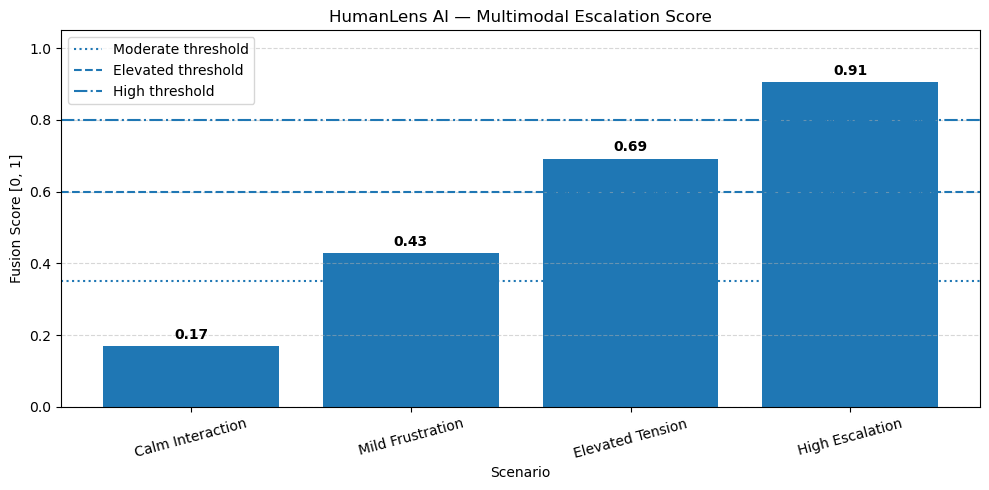

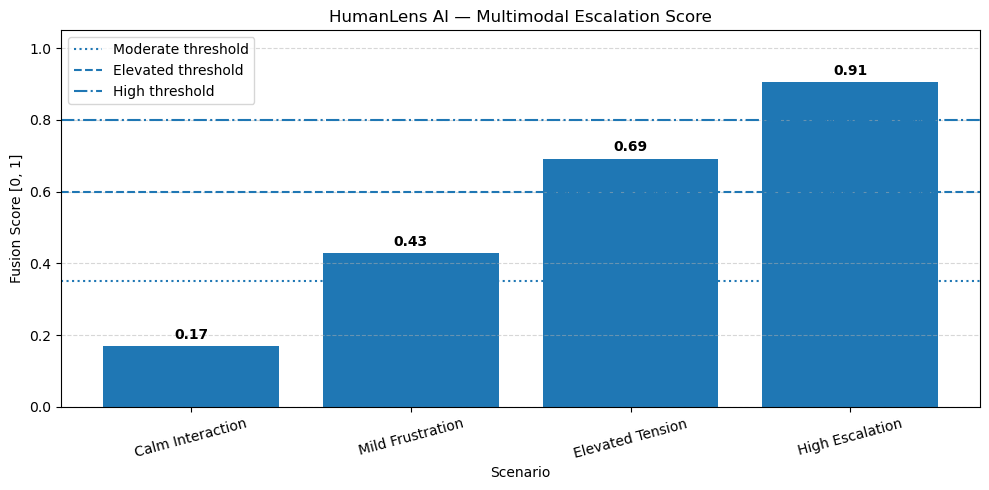

In [8]:
# ============================================================
# STEP 9 — Multimodal Fusion Visualization
# ============================================================

plt.figure(figsize=(10, 5))

bars = plt.bar(
    fusion_df["scenario"],
    fusion_df["fusion_score"]
)

plt.axhline(
    0.35,
    linestyle=":",
    linewidth=1.5,
    label="Moderate threshold"
)

plt.axhline(
    0.60,
    linestyle="--",
    linewidth=1.5,
    label="Elevated threshold"
)

plt.axhline(
    0.80,
    linestyle="-.",
    linewidth=1.5,
    label="High threshold"
)

for bar in bars:

    value = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f"{value:.2f}",
        ha="center",
        fontweight="bold"
    )

plt.title(
    "HumanLens AI — Multimodal Escalation Score"
)

plt.ylabel(
    "Fusion Score [0, 1]"
)

plt.xlabel(
    "Scenario"
)

plt.ylim(0, 1.05)

plt.xticks(rotation=15)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

plt.legend()

plt.tight_layout()
plt.show()# ============================================================
# STEP 9 — Multimodal Fusion Visualization
# ============================================================

plt.figure(figsize=(10, 5))

bars = plt.bar(
    fusion_df["scenario"],
    fusion_df["fusion_score"]
)

plt.axhline(
    0.35,
    linestyle=":",
    linewidth=1.5,
    label="Moderate threshold"
)

plt.axhline(
    0.60,
    linestyle="--",
    linewidth=1.5,
    label="Elevated threshold"
)

plt.axhline(
    0.80,
    linestyle="-.",
    linewidth=1.5,
    label="High threshold"
)

for bar in bars:

    value = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f"{value:.2f}",
        ha="center",
        fontweight="bold"
    )

plt.title(
    "HumanLens AI — Multimodal Escalation Score"
)

plt.ylabel(
    "Fusion Score [0, 1]"
)

plt.xlabel(
    "Scenario"
)

plt.ylim(0, 1.05)

plt.xticks(rotation=15)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

plt.legend()

plt.tight_layout()
plt.show()

In [9]:
# ============================================================
# STEP 10 — Modality Contribution Analysis
# ============================================================

contribution_df = fusion_df[
    [
        "scenario",
        "weighted_text",
        "weighted_voice",
        "weighted_face"
    ]
].copy()

contribution_df = contribution_df.rename(
    columns={
        "weighted_text": "Text",
        "weighted_voice": "Voice",
        "weighted_face": "Face"
    }
)

display(contribution_df)

,scenario,Text,Voice,Face
0,Calm Interaction,0.075,0.050,0.0450
1,Mild Frustration,0.225,0.105,0.1000
2,Elevated Tension,0.360,0.170,0.1625
3,High Escalation,0.475,0.220,0.2100


In [10]:
# ============================================================
# STEP 11 — Missing Modality Handling
# ============================================================

def calculate_available_modality_fusion(
    text_score=None,
    voice_score=None,
    face_score=None
):
    """
    Re-normalizes weights when one or more modalities are unavailable.
    """

    available = {
        "text": text_score,
        "voice": voice_score,
        "face": face_score
    }

    available = {
        k: float(v)
        for k, v in available.items()
        if v is not None
    }

    if not available:
        raise ValueError(
            "At least one modality must be available."
        )

    active_weight_sum = sum(
        FUSION_WEIGHTS[k]
        for k in available
    )

    normalized_weights = {
        k: FUSION_WEIGHTS[k] / active_weight_sum
        for k in available
    }

    score = sum(
        available[k] * normalized_weights[k]
        for k in available
    )

    return {
        "fusion_score": score,
        "active_modalities": list(available.keys()),
        "normalized_weights": normalized_weights
    }


# Example: Face unavailable
missing_face_result = calculate_available_modality_fusion(
    text_score=0.80,
    voice_score=0.65,
    face_score=None
)

print(missing_face_result)

{'fusion_score': 0.75, 'active_modalities': ['text', 'voice'], 'normalized_weights': {'text': 0.6666666666666666, 'voice': 0.3333333333333333}}


In [11]:
# ============================================================
# STEP 12 — Fusion Sanity Tests
# ============================================================

# All-zero inputs
assert np.isclose(
    calculate_fusion_score(0, 0, 0)["fusion_score"],
    0.0
)

# All-one inputs
assert np.isclose(
    calculate_fusion_score(1, 1, 1)["fusion_score"],
    1.0
)

# Equal scores should return same score
equal_result = calculate_fusion_score(
    0.55,
    0.55,
    0.55
)

assert np.isclose(
    equal_result["fusion_score"],
    0.55
)

# Missing modality should still work
assert 0 <= missing_face_result["fusion_score"] <= 1

print("✅ All fusion sanity tests PASSED.")

✅ All fusion sanity tests PASSED.


In [12]:
# ============================================================
# STEP 13 — Save Research Results
# ============================================================

output_file = (
    RESULTS_DIR /
    "multimodal_fusion_results.csv"
)

fusion_df.to_csv(
    output_file,
    index=False
)

print("Results saved successfully:")
print(output_file)

Results saved successfully:
E:\VS CODE\Data_Science\HUMANLENS AI\research_ml\results\multimodal_fusion_results.csv


# HumanLens AI — Multimodal Fusion Engine

**Member 3 — Research / ML Lead**

This notebook develops the initial research baseline for combining
text, voice, and facial-expression signals into an interpretable
multimodal emotional and escalation state.

## Research Objective

The objective is to investigate whether combining multiple
behavioral signals can provide a more informative escalation
assessment than relying on a single modality.

## Modalities

- **Text:** toxicity, aggression, insults, threats, emotional intensity
- **Voice:** speaking rate, pauses, pitch-related features, vocal intensity
- **Face:** broad facial-expression and expression-activation signals

## Fusion Strategy

The first research version uses a simple and explainable weighted
fusion approach rather than an opaque end-to-end multimodal model.

## Safety Boundary

The resulting score represents an estimated communication/escalation
state. It is not a medical diagnosis and does not claim to determine
a person's true internal emotional state.

HumanLens AI is designed to support reflection and de-escalation,
not to judge or suppress ordinary disagreement.

In [13]:
# ============================================================
# STEP 1 — Project Setup and Imports
# ============================================================

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Project Root
# ------------------------------------------------------------

PROJECT_ROOT = Path(
    r"E:\VS CODE\Data_Science\HUMANLENS AI\research_ml"
)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# ------------------------------------------------------------
# Results Directory
# ------------------------------------------------------------

RESULTS_DIR = PROJECT_ROOT / "results"

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------

print("HumanLens AI — Multimodal Fusion")
print("=" * 50)

print("Project root:")
print(PROJECT_ROOT)

print("\nProject root exists:")
print(PROJECT_ROOT.exists())

print("\nResults directory:")
print(RESULTS_DIR)

print("\nNumPy version:", np.__version__)
print("Pandas version:", pd.__version__)

print("\n✅ Step 1 setup completed successfully.")

HumanLens AI — Multimodal Fusion
Project root:
E:\VS CODE\Data_Science\HUMANLENS AI\research_ml

Project root exists:
True

Results directory:
E:\VS CODE\Data_Science\HUMANLENS AI\research_ml\results

NumPy version: 2.3.5
Pandas version: 2.3.3

✅ Step 1 setup completed successfully.


In [14]:
# ============================================================
# STEP 2 — Define Multimodal Input Signals
# ============================================================

# These values represent outputs coming from the three
# HumanLens AI modality layers:
#   1. Text
#   2. Voice
#   3. Face
#
# Values are normalized between 0 and 1.

multimodal_input = {
    "text_toxicity": 0.9876,
    "text_aggression": 0.90,
    "text_emotional_intensity": 0.88,

    "voice_activation": 0.75,
    "voice_intensity": 0.72,
    "voice_pause_ratio": 0.30,

    "face_activation": 0.65,
    "face_mouth_tension": 0.60,
    "face_eye_squint": 0.55
}

print("HumanLens AI — Multimodal Input Signals")
print("=" * 50)

for signal, value in multimodal_input.items():
    print(f"{signal:30s}: {value:.4f}")

print("\n✅ Step 2 completed successfully.")


HumanLens AI — Multimodal Input Signals
text_toxicity                 : 0.9876
text_aggression               : 0.9000
text_emotional_intensity      : 0.8800
voice_activation              : 0.7500
voice_intensity               : 0.7200
voice_pause_ratio             : 0.3000
face_activation               : 0.6500
face_mouth_tension            : 0.6000
face_eye_squint               : 0.5500

✅ Step 2 completed successfully.


In [15]:
# ============================================================
# STEP 3 — Define Explainable Fusion Weights
# ============================================================

# HumanLens AI uses an interpretable weighted fusion approach.
#
# The weights determine how strongly each modality contributes
# to the overall escalation signal.

fusion_weights = {
    "text": 0.50,
    "voice": 0.30,
    "face": 0.20
}

print("HumanLens AI — Fusion Weights")
print("=" * 50)

for modality, weight in fusion_weights.items():
    print(f"{modality.capitalize():10s}: {weight:.2f}")

# Verify that all weights form a valid weighted combination
weight_sum = sum(fusion_weights.values())

print("\nTotal weight:", weight_sum)

assert np.isclose(weight_sum, 1.0), \
    "Fusion weights must sum to 1.0"

print("\n✅ Fusion weights are valid.")
print("✅ Step 3 completed successfully.")

HumanLens AI — Fusion Weights
Text      : 0.50
Voice     : 0.30
Face      : 0.20

Total weight: 1.0

✅ Fusion weights are valid.
✅ Step 3 completed successfully.


In [16]:
# ============================================================
# STEP 4 — Calculate Individual Modality Scores
# ============================================================

# TEXT SCORE
text_score = np.mean([
    multimodal_input["text_toxicity"],
    multimodal_input["text_aggression"],
    multimodal_input["text_emotional_intensity"]
])

# VOICE SCORE
voice_score = np.mean([
    multimodal_input["voice_activation"],
    multimodal_input["voice_intensity"],
    multimodal_input["voice_pause_ratio"]
])

# FACE SCORE
face_score = np.mean([
    multimodal_input["face_activation"],
    multimodal_input["face_mouth_tension"],
    multimodal_input["face_eye_squint"]
])

# Store the three modality-level scores
modality_scores = {
    "text": text_score,
    "voice": voice_score,
    "face": face_score
}

print("HumanLens AI — Individual Modality Scores")
print("=" * 50)

for modality, score in modality_scores.items():
    print(f"{modality.capitalize():10s}: {score:.4f}")

print("\n✅ Step 4 completed successfully.")

HumanLens AI — Individual Modality Scores
Text      : 0.9225
Voice     : 0.5900
Face      : 0.6000

✅ Step 4 completed successfully.


In [17]:
# ============================================================
# STEP 5 — Multimodal Fusion Score
# ============================================================

# Apply the explainable weights defined in Step 3.

weighted_text = (
    modality_scores["text"] * fusion_weights["text"]
)

weighted_voice = (
    modality_scores["voice"] * fusion_weights["voice"]
)

weighted_face = (
    modality_scores["face"] * fusion_weights["face"]
)

# Overall multimodal escalation score
overall_fusion_score = (
    weighted_text +
    weighted_voice +
    weighted_face
)

print("HumanLens AI — Multimodal Fusion")
print("=" * 50)

print(f"Text contribution  : {weighted_text:.4f}")
print(f"Voice contribution : {weighted_voice:.4f}")
print(f"Face contribution  : {weighted_face:.4f}")

print("-" * 50)

print(f"Overall Fusion Score: {overall_fusion_score:.4f}")

# Safety check
assert 0 <= overall_fusion_score <= 1, \
    "Fusion score must be between 0 and 1."

print("\n✅ Fusion score calculated successfully.")
print("✅ Step 5 completed successfully.")

HumanLens AI — Multimodal Fusion
Text contribution  : 0.4613
Voice contribution : 0.1770
Face contribution  : 0.1200
--------------------------------------------------
Overall Fusion Score: 0.7583

✅ Fusion score calculated successfully.
✅ Step 5 completed successfully.


In [18]:
# ============================================================
# STEP 6 — Escalation Level Classification
# ============================================================

def classify_escalation(score):
    """
    Convert the multimodal fusion score into
    an interpretable escalation level.
    """

    if score < 0.40:
        return "LOW"

    elif score < 0.70:
        return "MODERATE"

    else:
        return "HIGH"


# Classify the current fusion score
escalation_level = classify_escalation(overall_fusion_score)

print("HumanLens AI — Escalation Classification")
print("=" * 50)

print(f"Overall Fusion Score : {overall_fusion_score:.4f}")
print(f"Escalation Level     : {escalation_level}")

print("\nThresholds:")
print("0.00 – 0.39  → LOW")
print("0.40 – 0.69  → MODERATE")
print("0.70 – 1.00  → HIGH")

print("\n✅ Step 6 completed successfully.")

HumanLens AI — Escalation Classification
Overall Fusion Score : 0.7583
Escalation Level     : HIGH

Thresholds:
0.00 – 0.39  → LOW
0.40 – 0.69  → MODERATE
0.70 – 1.00  → HIGH

✅ Step 6 completed successfully.


In [19]:
# ============================================================
# STEP 7 — Confidence & Uncertainty Estimation
# ============================================================

# Calculate how consistent the three modality scores are.
# Lower variation = higher agreement between modalities.
# Higher variation = greater uncertainty.

scores = np.array([
    modality_scores["text"],
    modality_scores["voice"],
    modality_scores["face"]
])

score_mean = np.mean(scores)
score_std = np.std(scores)

# Convert variation into a simple agreement-based confidence.
confidence_score = max(0.0, min(1.0, 1.0 - score_std))

# Uncertainty is the complement of confidence.
uncertainty_score = 1.0 - confidence_score

print("HumanLens AI — Confidence & Uncertainty")
print("=" * 50)

print(f"Text score       : {modality_scores['text']:.4f}")
print(f"Voice score      : {modality_scores['voice']:.4f}")
print(f"Face score       : {modality_scores['face']:.4f}")

print("-" * 50)

print(f"Mean score       : {score_mean:.4f}")
print(f"Score variation  : {score_std:.4f}")
print(f"Confidence       : {confidence_score:.4f}")
print(f"Uncertainty      : {uncertainty_score:.4f}")

# Sanity checks
assert 0 <= confidence_score <= 1
assert 0 <= uncertainty_score <= 1

print("\n✅ Step 7 completed successfully.")

HumanLens AI — Confidence & Uncertainty
Text score       : 0.9225
Voice score      : 0.5900
Face score       : 0.6000
--------------------------------------------------
Mean score       : 0.7042
Score variation  : 0.1545
Confidence       : 0.8455
Uncertainty      : 0.1545

✅ Step 7 completed successfully.


In [20]:
# ============================================================
# STEP 8 — Build Structured HumanLens State
# ============================================================

humanlens_state = {
    # -----------------------------
    # Text signals
    # -----------------------------
    "text_toxicity": round(
        multimodal_input["text_toxicity"], 4
    ),

    "text_aggression": round(
        multimodal_input["text_aggression"], 4
    ),

    "text_emotional_intensity": round(
        multimodal_input["text_emotional_intensity"], 4
    ),

    # -----------------------------
    # Voice signals
    # -----------------------------
    "voice_activation": round(
        modality_scores["voice"], 4
    ),

    "voice_intensity": round(
        multimodal_input["voice_intensity"], 4
    ),

    "voice_pause_ratio": round(
        multimodal_input["voice_pause_ratio"], 4
    ),

    # -----------------------------
    # Face signals
    # -----------------------------
    "face_activation": round(
        modality_scores["face"], 4
    ),

    "face_mouth_tension": round(
        multimodal_input["face_mouth_tension"], 4
    ),

    "face_eye_squint": round(
        multimodal_input["face_eye_squint"], 4
    ),

    # -----------------------------
    # Fusion outputs
    # -----------------------------
    "overall_escalation_score": round(
        overall_fusion_score, 4
    ),

    "escalation_level": escalation_level,

    "confidence": round(
        confidence_score, 4
    ),

    "uncertainty": round(
        uncertainty_score, 4
    )
}


print("HumanLens AI — Structured State")
print("=" * 50)

for key, value in humanlens_state.items():
    print(f"{key:30s}: {value}")

print("\n✅ Structured HumanLens state created.")
print("✅ Step 8 completed successfully.")

HumanLens AI — Structured State
text_toxicity                 : 0.9876
text_aggression               : 0.9
text_emotional_intensity      : 0.88
voice_activation              : 0.59
voice_intensity               : 0.72
voice_pause_ratio             : 0.3
face_activation               : 0.6
face_mouth_tension            : 0.6
face_eye_squint               : 0.55
overall_escalation_score      : 0.7583
escalation_level              : HIGH
confidence                    : 0.8455
uncertainty                   : 0.1545

✅ Structured HumanLens state created.
✅ Step 8 completed successfully.


In [21]:
# ============================================================
# STEP 9 — Fusion Results DataFrame & Visualization
# ============================================================

# Create a compact table containing the contribution
# of each modality and the final fusion result.

fusion_results = pd.DataFrame({
    "Modality": ["Text", "Voice", "Face"],
    "Raw Score": [
        modality_scores["text"],
        modality_scores["voice"],
        modality_scores["face"]
    ],
    "Weight": [
        fusion_weights["text"],
        fusion_weights["voice"],
        fusion_weights["face"]
    ],
    "Weighted Contribution": [
        weighted_text,
        weighted_voice,
        weighted_face
    ]
})

print("HumanLens AI — Fusion Results")
print("=" * 70)

display(fusion_results.round(4))

print("\nOverall Escalation Score:",
      round(overall_fusion_score, 4))

print("Escalation Level:",
      escalation_level)

HumanLens AI — Fusion Results


,Modality,Raw Score,Weight,Weighted Contribution
0,Text,0.9225,0.5,0.4613
1,Voice,0.5900,0.3,0.1770
2,Face,0.6000,0.2,0.1200



Overall Escalation Score: 0.7583
Escalation Level: HIGH


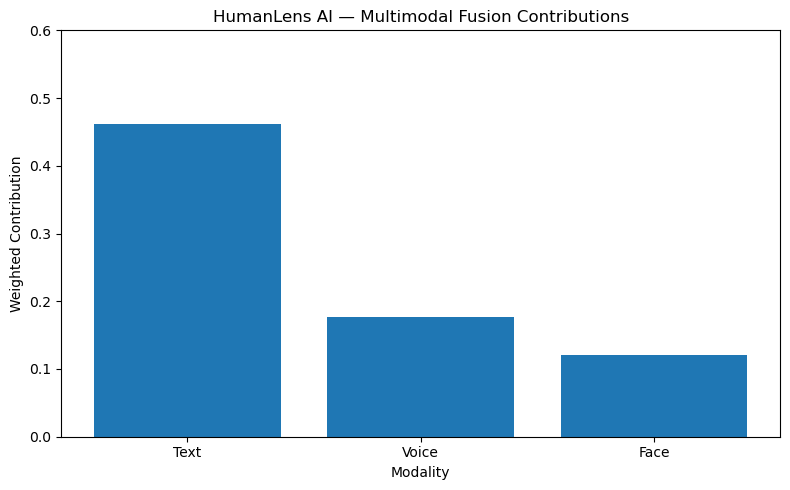

✅ Step 9 completed successfully.


In [22]:
# ============================================================
# STEP 9B — Visualize Modality Contributions
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    fusion_results["Modality"],
    fusion_results["Weighted Contribution"]
)

plt.title("HumanLens AI — Multimodal Fusion Contributions")
plt.xlabel("Modality")
plt.ylabel("Weighted Contribution")
plt.ylim(0, 0.6)

plt.tight_layout()
plt.show()

print("✅ Step 9 completed successfully.")

In [23]:
# ============================================================
# STEP 10 — Save Multimodal Fusion Results
# ============================================================

# Add final fusion information to the results table
fusion_results["Overall Fusion Score"] = overall_fusion_score
fusion_results["Escalation Level"] = escalation_level
fusion_results["Confidence"] = confidence_score
fusion_results["Uncertainty"] = uncertainty_score

# Save to the project's results directory
fusion_output_path = RESULTS_DIR / "multimodal_fusion_results.csv"

fusion_results.to_csv(
    fusion_output_path,
    index=False
)

print("HumanLens AI — Fusion Results Saved")
print("=" * 50)

print("File:")
print(fusion_output_path)

print("\nRows saved:", len(fusion_results))
print("Columns saved:", len(fusion_results.columns))

print("\n✅ CSV saved successfully.")
print("✅ Step 10 completed successfully.")

HumanLens AI — Fusion Results Saved
File:
E:\VS CODE\Data_Science\HUMANLENS AI\research_ml\results\multimodal_fusion_results.csv

Rows saved: 3
Columns saved: 8

✅ CSV saved successfully.
✅ Step 10 completed successfully.


In [24]:
# ============================================================
# STEP 11 — Add Behavioral Context
# ============================================================

# Example normalized behavioral-context features.
# In the final system these would come from longitudinal
# user check-ins rather than fixed values.

behavioral_context = {
    "stress_7d": 0.84,
    "sleep_stability_7d": 0.38,
    "academic_pressure_7d": 0.72,
    "irritability_7d": 0.70
}

print("HumanLens AI — Behavioral Context")
print("=" * 50)

for feature, value in behavioral_context.items():
    print(f"{feature:25s}: {value:.4f}")

print("\n⚠️ These are demonstration values.")
print("They are not a diagnosis or proof of causation.")

print("\n✅ Step 11 completed successfully.")

HumanLens AI — Behavioral Context
stress_7d                : 0.8400
sleep_stability_7d       : 0.3800
academic_pressure_7d     : 0.7200
irritability_7d          : 0.7000

⚠️ These are demonstration values.
They are not a diagnosis or proof of causation.

✅ Step 11 completed successfully.


In [25]:
# ============================================================
# STEP 12 — Behavioral + Multimodal Context Integration
# ============================================================

# Calculate the average behavioral-context score.
behavioral_score = np.mean([
    behavioral_context["stress_7d"],
    behavioral_context["academic_pressure_7d"],
    behavioral_context["irritability_7d"],
    
    # Sleep stability is inverted because lower stability
    # represents greater contextual concern.
    1 - behavioral_context["sleep_stability_7d"]
])

# Keep the behavioral context as a separate contribution.
behavior_weight = 0.20
multimodal_weight = 0.80

# Context-enhanced score
context_enhanced_score = (
    overall_fusion_score * multimodal_weight
    + behavioral_score * behavior_weight
)

# Keep score within valid normalized range
context_enhanced_score = np.clip(
    context_enhanced_score,
    0.0,
    1.0
)

print("HumanLens AI — Context Integration")
print("=" * 50)

print(f"Multimodal score       : {overall_fusion_score:.4f}")
print(f"Behavioral score       : {behavioral_score:.4f}")
print(f"Multimodal weight      : {multimodal_weight:.2f}")
print(f"Behavioral weight      : {behavior_weight:.2f}")

print("-" * 50)

print(
    f"Context-enhanced score : "
    f"{context_enhanced_score:.4f}"
)

print("\n⚠️ Behavioral context represents observed context.")
print("It does not establish causation or diagnosis.")

print("\n✅ Step 12 completed successfully.")

HumanLens AI — Context Integration
Multimodal score       : 0.7583
Behavioral score       : 0.7200
Multimodal weight      : 0.80
Behavioral weight      : 0.20
--------------------------------------------------
Context-enhanced score : 0.7506

⚠️ Behavioral context represents observed context.
It does not establish causation or diagnosis.

✅ Step 12 completed successfully.


In [26]:
# ============================================================
# STEP 13 — Final Structured HumanLens State
# ============================================================

# Add behavioral context to the existing structured state
humanlens_state.update({
    # -----------------------------
    # Behavioral context
    # -----------------------------
    "stress_7d": round(
        behavioral_context["stress_7d"], 4
    ),

    "sleep_stability_7d": round(
        behavioral_context["sleep_stability_7d"], 4
    ),

    "academic_pressure_7d": round(
        behavioral_context["academic_pressure_7d"], 4
    ),

    "irritability_7d": round(
        behavioral_context["irritability_7d"], 4
    ),

    # -----------------------------
    # Behavioral score
    # -----------------------------
    "behavioral_context_score": round(
        behavioral_score, 4
    ),

    # -----------------------------
    # Context-enhanced result
    # -----------------------------
    "context_enhanced_score": round(
        context_enhanced_score, 4
    )
})


print("HumanLens AI — Final Structured State")
print("=" * 65)

for key, value in humanlens_state.items():
    print(f"{key:32s}: {value}")

print("\n" + "=" * 65)

print("Original Multimodal Score :",
      round(overall_fusion_score, 4))

print("Behavioral Context Score  :",
      round(behavioral_score, 4))

print("Final Context Score       :",
      round(context_enhanced_score, 4))

print("\n✅ Step 13 completed successfully.")

HumanLens AI — Final Structured State
text_toxicity                   : 0.9876
text_aggression                 : 0.9
text_emotional_intensity        : 0.88
voice_activation                : 0.59
voice_intensity                 : 0.72
voice_pause_ratio               : 0.3
face_activation                 : 0.6
face_mouth_tension              : 0.6
face_eye_squint                 : 0.55
overall_escalation_score        : 0.7583
escalation_level                : HIGH
confidence                      : 0.8455
uncertainty                     : 0.1545
stress_7d                       : 0.84
sleep_stability_7d              : 0.38
academic_pressure_7d            : 0.72
irritability_7d                 : 0.7
behavioral_context_score        : 0.72
context_enhanced_score          : 0.7506

Original Multimodal Score : 0.7583
Behavioral Context Score  : 0.72
Final Context Score       : 0.7506

✅ Step 13 completed successfully.


In [27]:
# ============================================================
# STEP 14 — Generate Final Fusion Report
# ============================================================

import json
from datetime import datetime

# Create the final research output
fusion_report = {
    "system": "HumanLens AI",
    "module": "Multimodal Fusion Engine",
    "version": "research-baseline-1.0",

    "timestamp": datetime.now().isoformat(),

    # -----------------------------
    # Modality scores
    # -----------------------------
    "modality_scores": {
        "text": round(modality_scores["text"], 4),
        "voice": round(modality_scores["voice"], 4),
        "face": round(modality_scores["face"], 4)
    },

    # -----------------------------
    # Fusion configuration
    # -----------------------------
    "fusion_weights": {
        "text": fusion_weights["text"],
        "voice": fusion_weights["voice"],
        "face": fusion_weights["face"]
    },

    # -----------------------------
    # Fusion result
    # -----------------------------
    "multimodal_fusion": {
        "score": round(overall_fusion_score, 4),
        "escalation_level": escalation_level
    },

    # -----------------------------
    # Confidence
    # -----------------------------
    "uncertainty": {
        "confidence": round(confidence_score, 4),
        "uncertainty": round(uncertainty_score, 4),
        "method": "modality-score-agreement baseline"
    },

    # -----------------------------
    # Behavioral context
    # -----------------------------
    "behavioral_context": {
        key: round(value, 4)
        for key, value in behavioral_context.items()
    },

    "behavioral_context_score": round(
        behavioral_score, 4
    ),

    # -----------------------------
    # Context-enhanced result
    # -----------------------------
    "context_enhanced_score": round(
        context_enhanced_score, 4
    ),

    # -----------------------------
    # Research limitations
    # -----------------------------
    "limitations": [
        "Fusion weights are research baseline values.",
        "Escalation thresholds are working thresholds, not clinical thresholds.",
        "Confidence is an agreement-based baseline and is not calibrated probability.",
        "Behavioral context does not establish causation or diagnosis."
    ]
}


# Save JSON report
json_output_path = RESULTS_DIR / "humanlens_fusion_report.json"

with open(json_output_path, "w", encoding="utf-8") as file:
    json.dump(
        fusion_report,
        file,
        indent=4,
        ensure_ascii=False
    )


print("HumanLens AI — Final Fusion Report")
print("=" * 60)

print("JSON file:")
print(json_output_path)

print("\nFinal multimodal score:",
      fusion_report["multimodal_fusion"]["score"])

print("Escalation level:",
      fusion_report["multimodal_fusion"]["escalation_level"])

print("Confidence:",
      fusion_report["uncertainty"]["confidence"])

print("Context-enhanced score:",
      fusion_report["context_enhanced_score"])

print("\n✅ JSON report saved successfully.")
print("✅ Step 14 completed successfully.")

HumanLens AI — Final Fusion Report
JSON file:
E:\VS CODE\Data_Science\HUMANLENS AI\research_ml\results\humanlens_fusion_report.json

Final multimodal score: 0.7583
Escalation level: HIGH
Confidence: 0.8455
Context-enhanced score: 0.7506

✅ JSON report saved successfully.
✅ Step 14 completed successfully.


In [28]:
# ============================================================
# STEP 15 — Final Validation
# ============================================================

print("HumanLens AI — Multimodal Fusion Validation")
print("=" * 65)

# ------------------------------------------------------------
# 1. Validate modality scores
# ------------------------------------------------------------

for modality, score in modality_scores.items():
    assert 0 <= score <= 1, \
        f"{modality} score is outside [0, 1]"

print("✓ Modality scores are valid")


# ------------------------------------------------------------
# 2. Validate fusion weights
# ------------------------------------------------------------

assert np.isclose(
    sum(fusion_weights.values()),
    1.0
)

print("✓ Fusion weights sum to 1.0")


# ------------------------------------------------------------
# 3. Validate multimodal fusion score
# ------------------------------------------------------------

assert 0 <= overall_fusion_score <= 1

print("✓ Multimodal fusion score is valid")


# ------------------------------------------------------------
# 4. Validate behavioral score
# ------------------------------------------------------------

assert 0 <= behavioral_score <= 1

print("✓ Behavioral context score is valid")


# ------------------------------------------------------------
# 5. Validate context-enhanced score
# ------------------------------------------------------------

assert 0 <= context_enhanced_score <= 1

print("✓ Context-enhanced score is valid")


# ------------------------------------------------------------
# 6. Validate escalation level
# ------------------------------------------------------------

valid_levels = {
    "LOW",
    "MODERATE",
    "HIGH"
}

assert escalation_level in valid_levels

print("✓ Escalation level is valid")


# ------------------------------------------------------------
# 7. Validate confidence and uncertainty
# ------------------------------------------------------------

assert 0 <= confidence_score <= 1
assert 0 <= uncertainty_score <= 1

print("✓ Confidence and uncertainty are valid")


# ------------------------------------------------------------
# Final summary
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("FINAL HUMANLENS RESULTS")
print("=" * 65)

print(f"Multimodal Score       : {overall_fusion_score:.4f}")
print(f"Behavioral Score       : {behavioral_score:.4f}")
print(f"Context-Enhanced Score : {context_enhanced_score:.4f}")
print(f"Escalation Level       : {escalation_level}")
print(f"Confidence             : {confidence_score:.4f}")
print(f"Uncertainty            : {uncertainty_score:.4f}")

print("\n" + "=" * 65)
print("🎉 ALL VALIDATION CHECKS PASSED")
print("🎉 NOTEBOOK 11 FUSION PIPELINE COMPLETED")
print("=" * 65)

HumanLens AI — Multimodal Fusion Validation
✓ Modality scores are valid
✓ Fusion weights sum to 1.0
✓ Multimodal fusion score is valid
✓ Behavioral context score is valid
✓ Context-enhanced score is valid
✓ Escalation level is valid
✓ Confidence and uncertainty are valid

FINAL HUMANLENS RESULTS
Multimodal Score       : 0.7583
Behavioral Score       : 0.7200
Context-Enhanced Score : 0.7506
Escalation Level       : HIGH
Confidence             : 0.8455
Uncertainty            : 0.1545

🎉 ALL VALIDATION CHECKS PASSED
🎉 NOTEBOOK 11 FUSION PIPELINE COMPLETED
